In [1]:
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm

import sys
!{sys.executable} -m pip install wfdb -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import ast
import os
import warnings
warnings.filterwarnings('ignore')

# Now import wfdb after installation
import wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 4.1 MB/s eta 0:00:00


2025-11-14 23:48:14.754393: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763164095.020216      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763164095.087171      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")


TensorFlow version: 2.18.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# ============================================================================
# STEP 1: Load and Explore the Dataset
# ============================================================================

# Define the path to the dataset
DATA_PATH = '/kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1'

# Load the metadata
df = pd.read_csv(os.path.join(DATA_PATH, 'ptbxl_database.csv'), index_col='ecg_id')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

# Parse the string representations of lists/dicts
df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))

# Store original indices before any filtering
original_indices = df.index.copy()

Dataset shape: (21837, 27)

First few rows:
        patient_id   age  sex  height  weight  nurse  site     device  \
ecg_id                                                                  
1          15709.0  56.0    1     NaN    63.0    2.0   0.0  CS-12   E   
2          13243.0  19.0    0     NaN    70.0    2.0   0.0  CS-12   E   
3          20372.0  37.0    1     NaN    69.0    2.0   0.0  CS-12   E   
4          17014.0  24.0    0     NaN    82.0    2.0   0.0  CS-12   E   
5          17448.0  19.0    1     NaN    70.0    2.0   0.0  CS-12   E   

             recording_date                                  report  ...  \
ecg_id                                                               ...   
1       1984-11-09 09:17:34  sinusrhythmus periphere niederspannung  ...   
2       1984-11-14 12:55:37     sinusbradykardie sonst normales ekg  ...   
3       1984-11-15 12:49:10              sinusrhythmus normales ekg  ...   
4       1984-11-15 13:44:57              sinusrhythmus normales 

In [4]:
# ============================================================================
# STEP 2: Load ECG Signals
# ============================================================================

def load_raw_data(df, sampling_rate, path):
    """Load ECG signals from the dataset"""
    if sampling_rate == 100:
        filenames = df.filename_lr
    else:
        filenames = df.filename_hr
    
    data = []
    print(f"Loading {len(filenames)} ECG signals...")
    for f in tqdm(filenames, desc="Loading ECG data"):
        signal, meta = wfdb.rdsamp(os.path.join(path, f))
        data.append(signal)
    
    data = np.array(data)
    return data

# Load 100Hz data (you can change to 500 for higher resolution)
sampling_rate = 100
X = load_raw_data(df, sampling_rate, DATA_PATH)

print(f"\nECG signals shape: {X.shape}")
print(f"Signal dimensions: {X.shape[1]} samples x {X.shape[2]} leads")

Loading 21837 ECG signals...


Loading ECG data: 100%|██████████| 21837/21837 [04:25<00:00, 82.26it/s]



ECG signals shape: (21837, 1000, 12)
Signal dimensions: 1000 samples x 12 leads


In [5]:
# ============================================================================
# STEP 3: Prepare Labels
# ============================================================================

# Load SCP statements (diagnostic statements)
agg_df = pd.read_csv(os.path.join(DATA_PATH, 'scp_statements.csv'), index_col=0)

# Filter for diagnostic superclasses
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dic):
    """Aggregate diagnostic codes to superclasses"""
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply aggregation
df['diagnostic_superclass'] = df.scp_codes.apply(aggregate_diagnostic)

# Create mask for filtering BEFORE applying it
valid_mask = df.diagnostic_superclass.apply(len) > 0

# Now filter both dataframe and X array using the mask
df = df[valid_mask].copy()
X = X[valid_mask.values]

print(f"\nDataset after filtering: {df.shape}")
print(f"\nDiagnostic classes:")
print(df.diagnostic_superclass.explode().value_counts())

# Create multi-label binary matrix
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df.diagnostic_superclass.values)

print(f"\nFinal shapes:")
print(f"X: {X.shape}")
print(f"y: {y.shape}")
print(f"Classes: {mlb.classes_}")


Dataset after filtering: (21430, 28)

Diagnostic classes:
diagnostic_superclass
NORM    9528
MI      5486
STTC    5250
CD      4907
HYP     2655
Name: count, dtype: int64

Final shapes:
X: (21430, 1000, 12)
y: (21430, 5)
Classes: ['CD' 'HYP' 'MI' 'NORM' 'STTC']


In [6]:
# ============================================================================
# STEP 4: Split Data
# ============================================================================

# Use the official train/test split from PTB-XL
test_fold = 10
X_train = X[np.where(df.strat_fold != test_fold)]
y_train = y[np.where(df.strat_fold != test_fold)]
X_test = X[np.where(df.strat_fold == test_fold)]
y_test = y[np.where(df.strat_fold == test_fold)]

# Create validation set from training data (without stratification for multi-label)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, shuffle=True
)

print(f"\nData split:")
print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Val: {X_val.shape}, {y_val.shape}")
print(f"Test: {X_test.shape}, {y_test.shape}")



Data split:
Train: (17340, 1000, 12), (17340, 5)
Val: (1927, 1000, 12), (1927, 5)
Test: (2163, 1000, 12), (2163, 5)


In [7]:
# ============================================================================
# STEP 5: Normalize Data
# ============================================================================

# Normalize per lead
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_val = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

In [8]:

# ============================================================================
# STEP 6: Build CNN Model
# ============================================================================

def build_cnn_model(input_shape, num_classes):
    """Build a 1D CNN model for ECG classification"""
    
    model = keras.Sequential([
        # Block 1
        layers.Conv1D(64, kernel_size=7, padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.2),
        
        # Block 2
        layers.Conv1D(128, kernel_size=5, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.2),
        
        # Block 3
        layers.Conv1D(256, kernel_size=3, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.2),
        
        # Block 4
        layers.Conv1D(512, kernel_size=3, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.GlobalAveragePooling1D(),
        layers.Dropout(0.3),
        
        # Dense layers
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='sigmoid')
    ])
    
    return model

# Build model
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = y_train.shape[1]

model = build_cnn_model(input_shape, num_classes)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

model.summary()

I0000 00:00:1763164386.884705      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763164386.885418      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1000, 64)       │         5,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 500, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 500, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 500, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 500, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 250, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 250, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 250, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 125, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 125, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 125, 512)       │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 125, 512)       │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 125, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 675,269 (2.58 MB)

 Trainable params: 673,349 (2.57 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [9]:
# ============================================================================
# STEP 7: Train Model
# ============================================================================

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7
    )
]

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50


I0000 00:00:1763164394.998073      67 service.cc:148] XLA service 0x7ec658003660 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763164394.998879      67 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1763164394.998902      67 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1763164395.682358      67 cuda_dnn.cc:529] Loaded cuDNN version 90300


  5/271 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.2081 - auc: 0.5799 - loss: 0.6147

I0000 00:00:1763164402.657276      67 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


271/271 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.5690 - auc: 0.8347 - loss: 0.4147 - val_accuracy: 0.6757 - val_auc: 0.9122 - val_loss: 0.3303 - learning_rate: 0.0010
Epoch 2/50
271/271 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.6729 - auc: 0.9100 - loss: 0.3203 - val_accuracy: 0.6803 - val_auc: 0.9286 - val_loss: 0.2989 - learning_rate: 0.0010
Epoch 3/50
271/271 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.6882 - auc: 0.9207 - loss: 0.3013 - val_accuracy: 0.7182 - val_auc: 0.9387 - val_loss: 0.2722 - learning_rate: 0.0010
Epoch 4/50
271/271 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7006 - auc: 0.9276 - loss: 0.2890 - val_accuracy: 0.7032 - val_auc: 0.9391 - val_loss: 0.2677 - learning_rate: 0.0010
Epoch 5/50
271/271 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7022 - auc: 0.9296 - loss: 0.2843 - val_accuracy: 0.7120 - val_auc: 0.9447 - val_loss: 0.2573 - learning_rate: 0.0010
Epoch 6/50
271/271 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7095 - auc: 0.9342

In [10]:
# ============================================================================
# STEP 8: Evaluate Model
# ============================================================================

# Evaluate on test set
test_results = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Results:")
print(f"Loss: {test_results[0]:.4f}")
print(f"Accuracy: {test_results[1]:.4f}")
print(f"AUC: {test_results[2]:.4f}")

# Get predictions
y_pred = model.predict(X_test)

68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7048 - auc: 0.9370 - loss: 0.2889

Test Results:
Loss: 0.2972
Accuracy: 0.6921
AUC: 0.9339
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


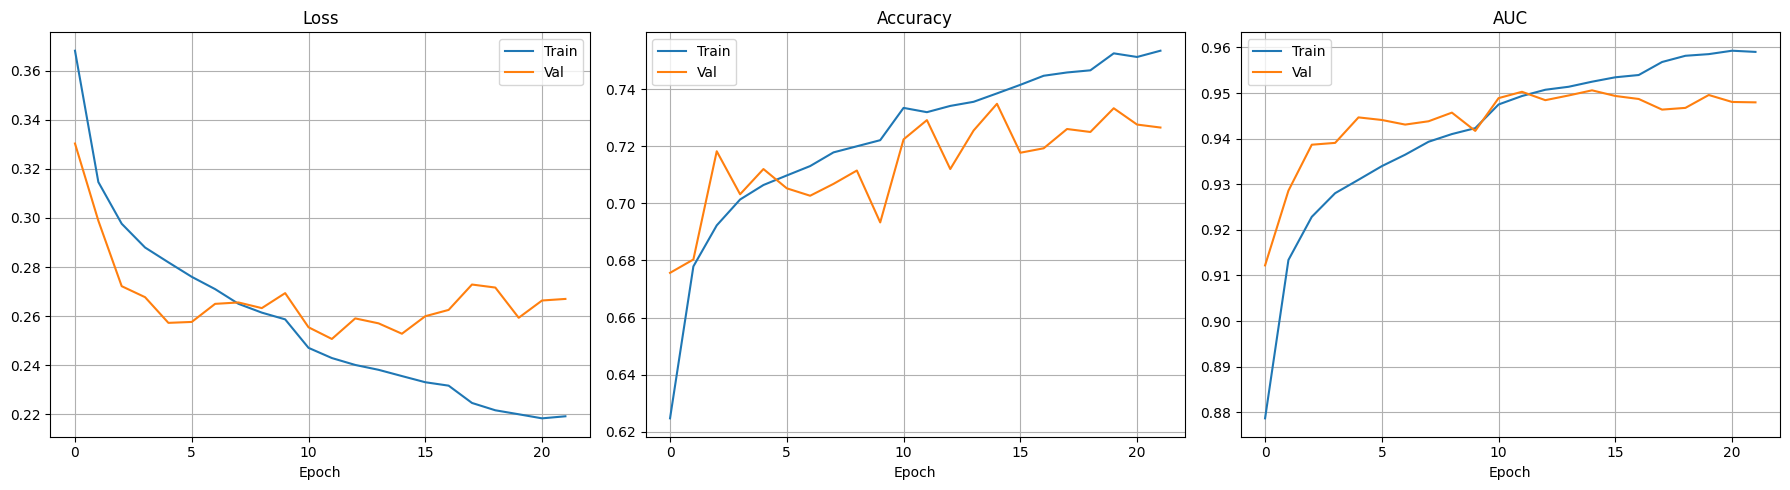

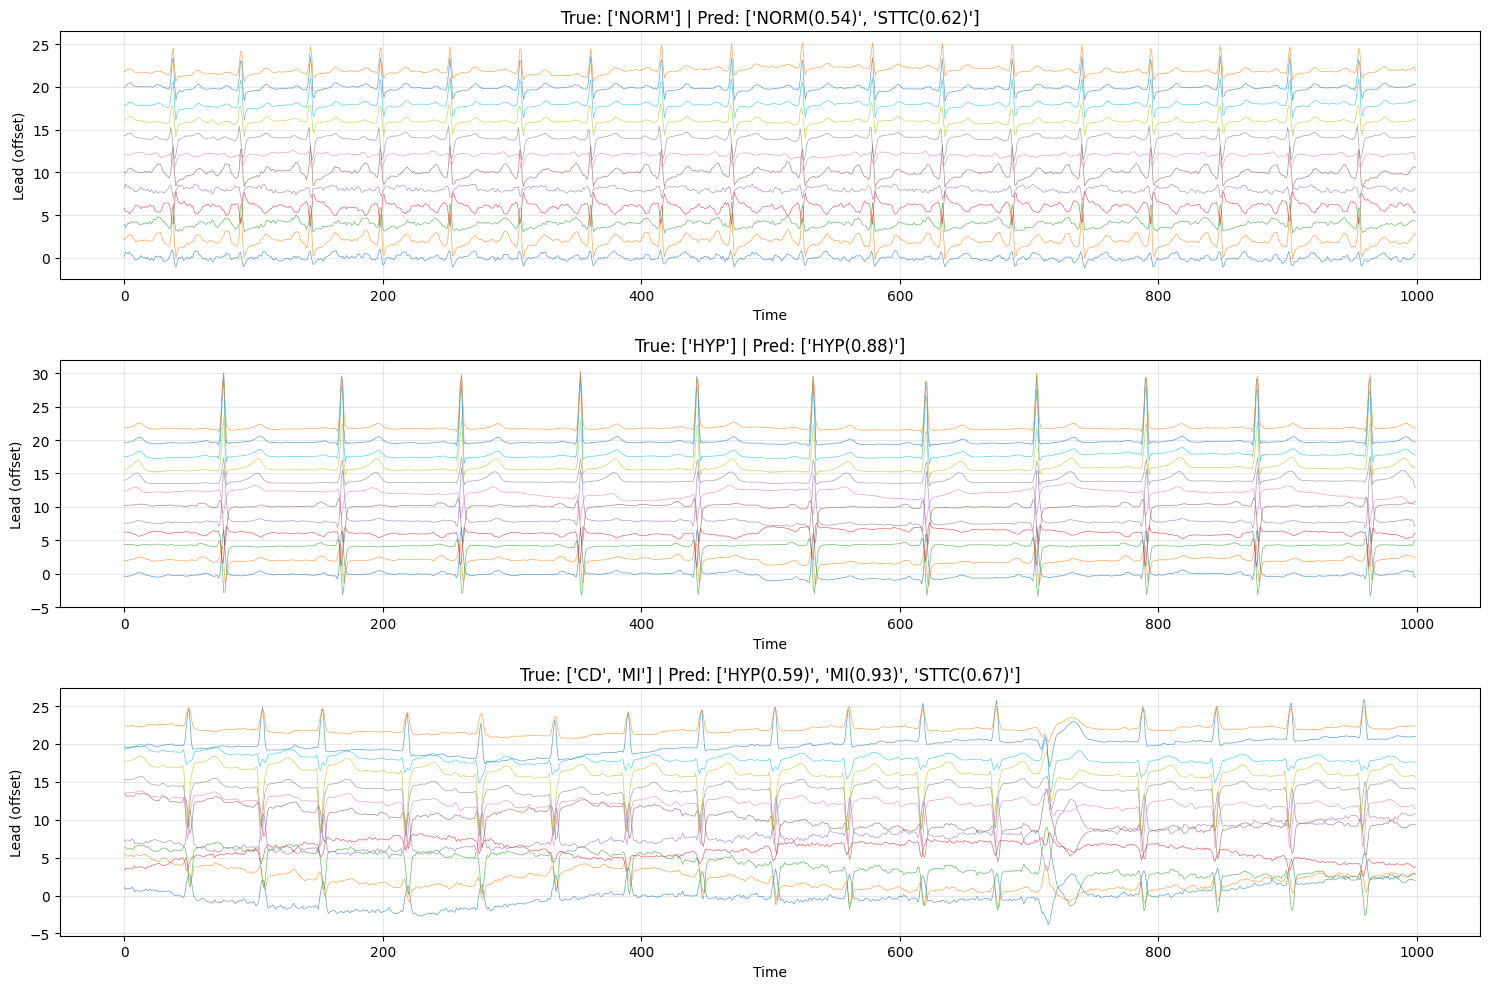

In [11]:
# ============================================================================
# STEP 9: Visualize Results
# ============================================================================

# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history.history['auc'], label='Train')
axes[2].plot(history.history['val_auc'], label='Val')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Plot sample predictions
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

for i in range(3):
    idx = np.random.randint(0, len(X_test))
    
    # Plot all 12 leads
    for lead in range(12):
        axes[i].plot(X_test[idx, :, lead] + lead*2, alpha=0.7, linewidth=0.5)
    
    true_classes = [mlb.classes_[j] for j in range(len(y_test[idx])) if y_test[idx][j] == 1]
    pred_classes = [f"{mlb.classes_[j]}({y_pred[idx][j]:.2f})" 
                   for j in range(len(y_pred[idx])) if y_pred[idx][j] > 0.5]
    
    axes[i].set_title(f"True: {true_classes} | Pred: {pred_classes}")
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Lead (offset)')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# ============================================================================
# STEP 10: Save Model
# ============================================================================

model.save('ptbxl_cnn_model.keras')
print("\nModel saved as 'ptbxl_cnn_model.keras'")

print("\n✓ Training complete!")


Model saved as 'ptbxl_cnn_model.keras'

✓ Training complete!
